<a href="https://colab.research.google.com/github/Ruhul73/customer-segmentation-using-K_Mean/blob/main/Customer_Segmentation_using_K_Means_Clustering_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Customer Segmentation Analysis

This notebook demonstrates a complete machine learning pipeline for customer segmentation, using K-Means clustering to identify distinct customer groups and a Decision Tree Classifier to predict these groups based on customer attributes. The goal is to provide actionable business insights for targeted marketing strategies.

# Importing Dependicies

This section is dedicated to importing all necessary Python libraries for data manipulation, visualization, machine learning, and logging. This ensures that all required functionalities are available throughout the notebook.

### Libraries Used:
- **`numpy`**: For numerical operations.
- **`pandas`**: For data manipulation and analysis.
- **`matplotlib.pyplot`**: For basic plotting and visualization.
- **`seaborn`**: For enhanced statistical data visualization.
- **`sklearn.cluster.KMeans`**: For K-Means clustering algorithm.
- **`sklearn.model_selection.train_test_split`**: For splitting data into training and testing sets.
- **`warnings`**: To manage warning messages.
- **`logging`**: For recording events and debugging information.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

In [2]:
import warnings
warnings.filterwarnings('ignore')

### Suppressing Warnings

This cell is used to suppress any warnings that might arise during the execution of the notebook. This is often done to keep the output clean and focused on essential information, especially in production or presentation notebooks.

In [3]:
import logging

# LOGGING SETUP (Black Box Record)
# Hum computer ko bata rahe hain: "Jo bhi ho, is file mein likhte jao"
logging.basicConfig(
    filename='customer_segmentation.log', # Log file ka naam
    level=logging.INFO,                   # Kis level ki details chahiye (INFO, ERROR, WARNING)
    format='%(asctime)s - %(levelname)s - %(message)s' # Time aur Message ka format
)

logging.info(">>> Project Started: Customer Segmentation Pipeline")

### Logging Setup

To ensure proper tracking and debugging, a logging system is configured. All significant events and information throughout the pipeline will be recorded in a log file named `customer_segmentation.log`. This helps in monitoring the execution flow and identifying potential issues.

# Data Collection & Analysis

> Add blockquote



## Data Collection & Initial Analysis

This section focuses on acquiring the dataset and performing initial exploratory data analysis (EDA) to understand its structure, content, and basic statistics. We will be using a customer segmentation dataset, typically containing customer demographics and spending habits.

In [4]:
import kagglehub
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.


### Data Download from KaggleHub

The dataset for this project is downloaded from KaggleHub using the `kagglehub` library. This ensures that the data is consistently sourced and available for replication. The dataset `vjchoudhary7/customer-segmentation-tutorial-in-python` is used.

### Loading the Dataset

The downloaded CSV file (`Mall_Customers.csv`) is loaded into a pandas DataFrame. This DataFrame, named `Customer`, will be the primary data structure for all subsequent analysis and modeling steps.

In [5]:
#Loading The Data From Csv File in a Pandas Dataframe
import pandas as pd
import os
x=os.path.join(path,"Mall_Customers.csv")
Customer=pd.read_csv(x)

In [6]:
logging.info("Data Loaded Successfully")

In [7]:
#first five rows in the Dataframe
Customer.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Previewing the Data

To get a quick overview of the dataset's structure and content, the `head()` method is used to display the first five rows. This helps in understanding the columns, data types, and the general format of the customer data.

# Findind the number of rows and coloumns

### Dataset Dimensions

This step determines the number of rows (observations) and columns (features) in the dataset using the `shape` attribute. It provides an immediate understanding of the dataset's size.

In [8]:
# Findind the number of rows and coloumns
Customer.shape

(200, 5)

# Getting Some information About the dataset

### Data Information Summary

The `info()` method provides a concise summary of the DataFrame, including the number of non-null entries for each column and their respective data types. This is crucial for identifying potential issues like missing values or incorrect data types.

In [9]:
Customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [10]:
# checking for missing values
Customer.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


### Checking for Missing Values

Missing values can significantly impact model performance. This step checks for any null entries across all columns using `isnull().sum()`, ensuring data completeness before proceeding with further analysis.

# Label Encoder

## Data Preprocessing

This section handles the preparation of the data for machine learning models. This includes encoding categorical variables and exploring relationships between features through correlation analysis.

### Label Encoding for Categorical Features

The 'Gender' column, being a categorical feature, needs to be converted into a numerical format for machine learning algorithms. `LabelEncoder` from `sklearn.preprocessing` is used to transform 'Male' and 'Female' into numerical labels (e.g., 0 and 1).

In [11]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
Customer['Gender']=le.fit_transform(Customer['Gender'])

In [12]:
Customer['Gender']

,Gender
0,1
1,1
2,0
3,0
4,0
...,...
195,0
196,0
197,1
198,1


### Correlation Matrix Analysis

A correlation heatmap is generated using `seaborn` to visualize the relationships between numerical features such as Age, Annual Income, and Spending Score. This helps in identifying highly correlated features and understanding their dependencies.

**Tools Used:**
- **`seaborn`**: For creating the heatmap.
- **`matplotlib.pyplot`**: For displaying the plot.

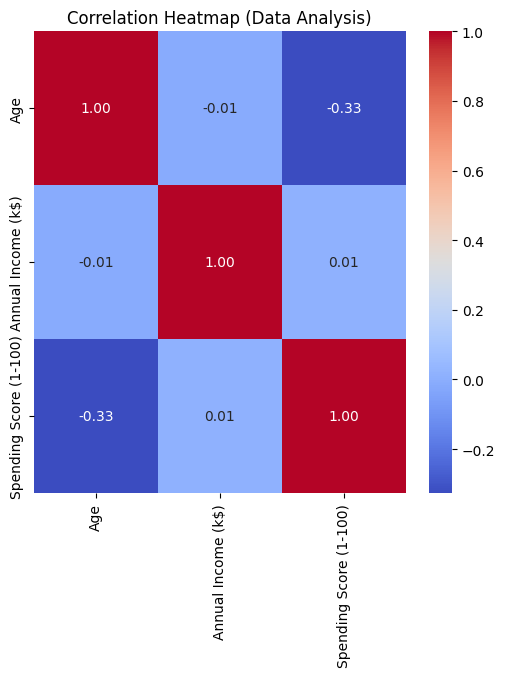

In [13]:
#  Professional EDA: Correlation Matrix
# Ye dekhne ke liye ke kya Age aur Score ka koi taluq hai? Ya Income aur Score ka?
plt.figure(figsize=(6, 6))
# Dropping 'ID' because it has no mathematical value, and 'Gender' for correlation map only
numeric_df = Customer.drop(['CustomerID', 'Gender'], axis=1)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Data Analysis)')
plt.show()

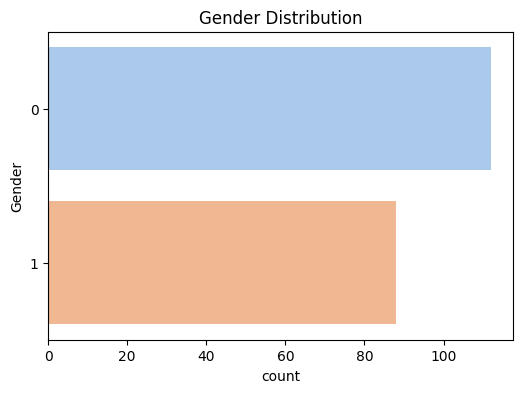

In [14]:
# 1.4 Distribution Plot (Gender Split)
plt.figure(figsize=(6, 4))
sns.countplot(y='Gender', data=Customer, palette='pastel')
plt.title('Gender Distribution')
plt.show()

### Gender Distribution Plot

This visualization shows the distribution of genders within the dataset. A `countplot` from `seaborn` is used to illustrate the count of 'Male' and 'Female' customers, providing insight into the gender balance of the customer base.

**Tools Used:**
- **`seaborn`**: For creating the count plot.
- **`matplotlib.pyplot`**: For displaying the plot.

# choosing the Annual Income & Soending Score

## Customer Segmentation with K-Means Clustering

This section focuses on segmenting customers into distinct groups based on their attributes using the K-Means clustering algorithm. We will first select the relevant features, scale them, and then determine the optimal number of clusters.

### Importing Clustering Libraries

Key libraries for clustering and evaluation are imported here:
- **`sklearn.preprocessing.StandardScaler`**: For scaling features.
- **`sklearn.cluster.KMeans`**: The core K-Means clustering algorithm.
- **`sklearn.metrics.silhouette_score`**: For evaluating clustering quality.

In [15]:
# Professional Libraries Import
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [16]:
# Feature Selection (Hum 3 cheezein use karenge: Age, Income, Score)
# Professional projects mein 'Age' bohot zaroori hoti hai pattern samajhne ke liye.
X_features = Customer.iloc[:, [2, 3, 4]].values  # Age, Income, Score

### Feature Selection for Clustering

For K-Means clustering, we select 'Age', 'Annual Income (k$)', and 'Spending Score (1-100)' as the features. These attributes are crucial for understanding customer behavior and demographics relevant to segmentation. The `.iloc` method is used to extract these columns.

### Feature Scaling

It is essential to scale the features before applying K-Means clustering, especially when features have different ranges. `StandardScaler` is used to transform the features such that they have a mean of 0 and a standard deviation of 1. This prevents features with larger values from dominating the distance calculations.

In [17]:
X_features

array([[ 19,  15,  39],
       [ 21,  15,  81],
       [ 20,  16,   6],
       [ 23,  16,  77],
       [ 31,  17,  40],
       [ 22,  17,  76],
       [ 35,  18,   6],
       [ 23,  18,  94],
       [ 64,  19,   3],
       [ 30,  19,  72],
       [ 67,  19,  14],
       [ 35,  19,  99],
       [ 58,  20,  15],
       [ 24,  20,  77],
       [ 37,  20,  13],
       [ 22,  20,  79],
       [ 35,  21,  35],
       [ 20,  21,  66],
       [ 52,  23,  29],
       [ 35,  23,  98],
       [ 35,  24,  35],
       [ 25,  24,  73],
       [ 46,  25,   5],
       [ 31,  25,  73],
       [ 54,  28,  14],
       [ 29,  28,  82],
       [ 45,  28,  32],
       [ 35,  28,  61],
       [ 40,  29,  31],
       [ 23,  29,  87],
       [ 60,  30,   4],
       [ 21,  30,  73],
       [ 53,  33,   4],
       [ 18,  33,  92],
       [ 49,  33,  14],
       [ 21,  33,  81],
       [ 42,  34,  17],
       [ 30,  34,  73],
       [ 36,  37,  26],
       [ 20,  37,  75],
       [ 65,  38,  35],
       [ 24,  38

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# Chosing the number of clustor

### Determining the Optimal Number of Clusters (K)

Choosing the right number of clusters (`k`) is critical for K-Means. This section uses two popular methods: the Elbow Method (WCSS) and the Silhouette Score.

#### WCSS (Within-Cluster Sum of Squares)
WCSS measures the sum of squared distances between each point and the centroid of its assigned cluster. The 'elbow' point in the WCSS plot indicates a good balance where adding more clusters doesn't significantly reduce the inertia.

#### Silhouette Score
The Silhouette Score measures how similar an object is to its own cluster compared to other clusters. A higher silhouette score indicates better-defined clusters.

**Tools Used:**
- **`KMeans`**: For performing clustering with different `k` values.
- **`silhouette_score`**: For calculating the silhouette metric.

## WCSS->within clustor sum of square

In [19]:
#  Finding Optimal 'k' (Elbow + Silhouette Method)
wcss = []
silhouette_scores = []
k_range = range(2, 11)

print("Processing optimal clusters... Please wait.")

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # Elbow Logic
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_)) # Accuracy Logic

Processing optimal clusters... Please wait.


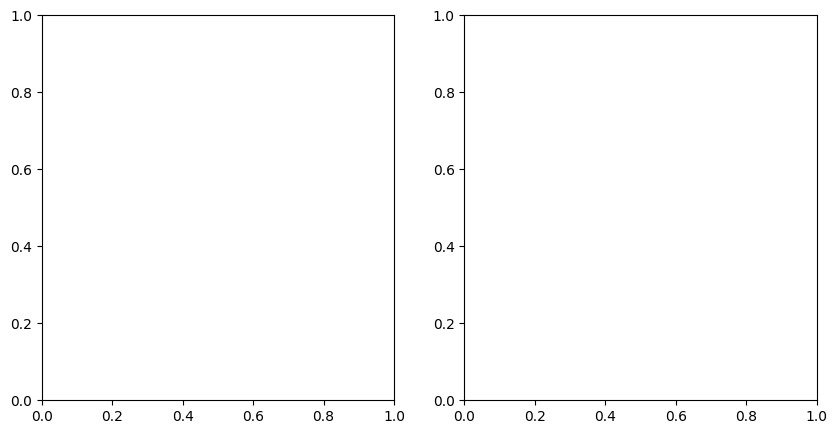

In [20]:
# Plotting Professional Graphs
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

In [21]:
#plot an elbow graph
ax[0].plot(range(2,11),wcss)
ax[0].set_title('Elbow Method (Inertia)')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('WCSS')
ax[0].grid(True)

In [22]:
# Graph  Silhouette Score (Validation)
ax[1].plot(k_range, silhouette_scores, marker='o', color='red')
ax[1].set_title('Silhouette Score Analysis (Higher is Better)')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Silhouette Score')
ax[1].grid(True)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

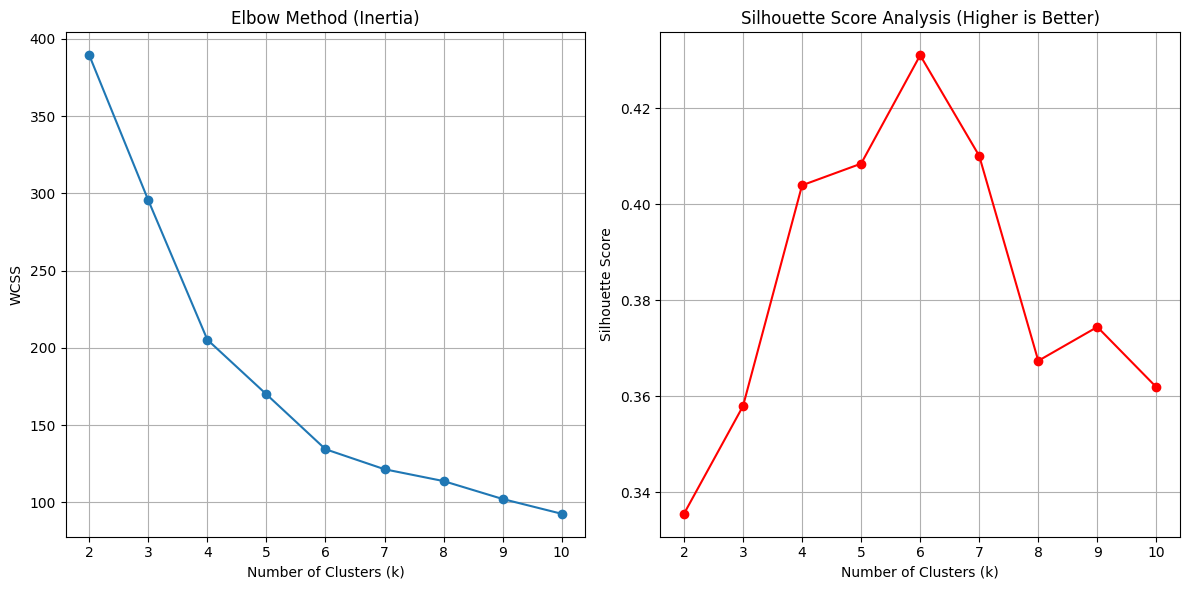

In [23]:
# Plotting Professional Graphs (Combined Cell)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot the Elbow Method (WCSS)
ax[0].plot(range(2, 11), wcss, marker='o')
ax[0].set_title('Elbow Method (Inertia)')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('WCSS')
ax[0].grid(True)

# Plot the Silhouette Score
ax[1].plot(k_range, silhouette_scores, marker='o', color='red')
ax[1].set_title('Silhouette Score Analysis (Higher is Better)')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Silhouette Score')
ax[1].grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

### Visualizing Elbow Method and Silhouette Score

Two plots are generated to help identify the optimal number of clusters (`k`):
1.  **Elbow Method (WCSS)**: Plots the WCSS against the number of clusters. The 'elbow' point suggests an appropriate `k`.
2.  **Silhouette Score Analysis**: Plots the silhouette score for different numbers of clusters. A higher score generally indicates better clustering.

These plots are crucial for making an informed decision about the `k` value for the K-Means algorithm.

**Tools Used:**
- **`matplotlib.pyplot`**: For creating and displaying the plots.
- **`seaborn`**: Can be used for aesthetic enhancements (though `plt` is used directly here).

# optimum number of cluster=5

### Optimal Number of Clusters

Based on the analysis from the Elbow Method and Silhouette Score, **5** is chosen as the optimal number of clusters for customer segmentation.

# training the k_means clustor model

### Training the K-Means Clustering Model

The K-Means model is initialized with the chosen optimal number of clusters (`n_clusters=5`) and trained on the scaled features (`X_scaled`). The `fit_predict` method assigns each data point to a cluster, and the resulting cluster labels are stored in the variable `y`.

In [24]:
kmeans=KMeans(n_clusters=5,init='k-means++',random_state=0)
# Return a label for each data point  based on the cluster
y=kmeans.fit_predict(X_scaled)
print(y)

[4 4 3 4 4 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 0 4 3 4 3 4 0 4 4 4 0 4 4 0 0 0 0 0 4 0 0 4 0 0 0 4 0 0 4 4 0 0 0 0
 0 4 0 0 4 0 0 4 0 0 4 0 0 4 4 0 0 4 0 0 4 4 0 4 0 4 4 0 0 4 0 4 0 0 0 0 0
 4 1 4 4 4 0 0 0 0 4 1 2 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 0 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2]


# visualizing all the cluster

### Visualizing Customer Clusters

This cell visualizes the customer segments in a 2D scatter plot, showing 'Annual Income' versus 'Spending Score'. Each cluster is represented by a different color, and the cluster centroids are marked with 'X'. The original centroids are inverse-transformed to be on the same scale as the plot.

**Tools Used:**
- **`matplotlib.pyplot`**: For creating the scatter plot and customizing its elements.

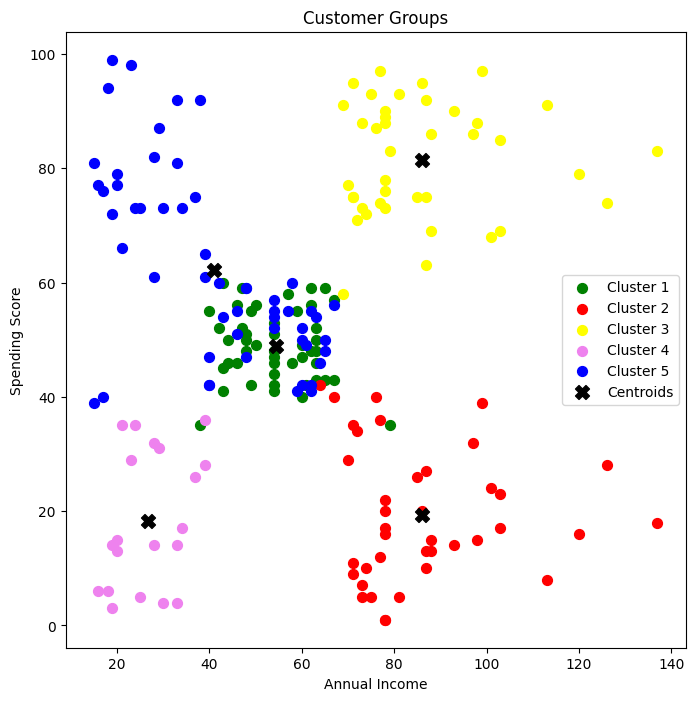

In [25]:
# Inverse transform the centroids back to their original scale
original_centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# Plotting all the clusters and their centroids
plt.figure(figsize=(8,8))

# Using original X_features for the points (as you already had)
plt.scatter(X_features[y==0,1], X_features[y==0,2], s=50, c='green', label='Cluster 1')
plt.scatter(X_features[y==1,1], X_features[y==1,2], s=50, c='red', label='Cluster 2')
plt.scatter(X_features[y==2,1], X_features[y==2,2], s=50, c='yellow', label='Cluster 3')
plt.scatter(X_features[y==3,1], X_features[y==3,2], s=50, c='violet', label='Cluster 4')
plt.scatter(X_features[y==4,1], X_features[y==4,2], s=50, c='blue', label='Cluster 5')

# FIX: Plot the newly unscaled centroids
plt.scatter(original_centroids[:,1], original_centroids[:,2], s=100, c='black', label='Centroids', marker='X')

plt.title('Customer Groups')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

In [26]:
logging.info("K-Means Clustering Complete")

# Decision Tree Classifier

## Predictive Modeling with Decision Tree Classifier

After identifying customer segments using unsupervised learning (K-Means), this section builds a supervised learning model (Decision Tree Classifier) to predict which cluster a new customer belongs to based on their 'Age' and 'Annual Income'. This model can then be used for automated customer classification.

### Importing Libraries for Supervised Learning

This cell imports the necessary libraries for building and evaluating a Decision Tree Classifier:
- **`sklearn.model_selection.GridSearchCV`**: For hyperparameter tuning.
- **`sklearn.model_selection.StratifiedKFold`**: For cross-validation.
- **`sklearn.pipeline.Pipeline`**: For streamlining machine learning workflows.
- **`sklearn.preprocessing.StandardScaler`**: For feature scaling (again, within the pipeline).
- **`sklearn.tree.DecisionTreeClassifier`**: The Decision Tree algorithm.
- **`sklearn.metrics.classification_report`**: For detailed model evaluation.
- **`sklearn.metrics.confusion_matrix`**: For visualizing model performance.
- **`seaborn` and `matplotlib.pyplot`**: For plotting results.

In [27]:
# SPREDICTION MODEL (Supervised Learning)

In [28]:
# Libraries Import
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
# Data Setup (The Realistic Approach)
# Hum Input (X) mein se 'Spending Score' nikal rahe hain taake cheating na ho.
# Model sirf Age aur Income dekh kar guess karega.
X = Customer[['Age', 'Annual Income (k$)']]
y = y # Aapke K-Means ke labels

### Data Setup for Classification

For the Decision Tree Classifier, the input features (`X`) are 'Age' and 'Annual Income (k$)', and the target variable (`y`) is the cluster labels generated by the K-Means model. The 'Spending Score' is excluded from `X` to simulate a real-world scenario where the model predicts the segment based on readily available customer information without direct knowledge of their spending behavior.

In [30]:
y

array([4, 4, 3, 4, 4, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 0, 4, 3, 4,
       3, 4, 0, 4, 4, 4, 0, 4, 4, 0, 0, 0, 0, 0, 4, 0, 0, 4, 0, 0, 0, 4,
       0, 0, 4, 4, 0, 0, 0, 0, 0, 4, 0, 0, 4, 0, 0, 4, 0, 0, 4, 0, 0, 4,
       4, 0, 0, 4, 0, 0, 4, 4, 0, 4, 0, 4, 4, 0, 0, 4, 0, 4, 0, 0, 0, 0,
       0, 4, 1, 4, 4, 4, 0, 0, 0, 0, 4, 1, 2, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2], dtype=int32)

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
# Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Train-Test Split

The dataset is split into training and testing sets using `train_test_split`. An 80/20 ratio is used, meaning 80% of the data is for training the model and 20% for evaluating its performance on unseen data. `random_state` ensures reproducibility.

In [33]:
X_test.shape , X_train.shape , y_test.shape , y_train.shape

((40, 2), (160, 2), (40,), (160,))

### Pipeline and Hyperparameter Tuning with GridSearchCV

A `Pipeline` is constructed to sequentially apply `StandardScaler` (for feature scaling) and `DecisionTreeClassifier`. This helps in preventing data leakage and ensures consistent preprocessing. `GridSearchCV` is then used to systematically search for the best combination of hyperparameters for the Decision Tree model, optimizing for accuracy through cross-validation.

**Pipeline Steps:**
1.  **`StandardScaler`**: Scales the input features.
2.  **`DecisionTreeClassifier`**: The classification model.

In [34]:
#  Pipeline & Grid Search (Hyperparameter Tuning)
# Pipeline setup
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('dt_model', DecisionTreeClassifier(random_state=42))
])

In [35]:
# Settings jo computer try karega (Best result dhundne ke liye)
param_grid = {
    'dt_model__max_depth': [2, 3, 4, 5, 6, 7],
    'dt_model__min_samples_leaf': [1, 5, 10],
    'dt_model__criterion': ['gini', 'entropy']
}

### Defining Hyperparameter Grid

The `param_grid` specifies the range of hyperparameters that `GridSearchCV` will explore for the `DecisionTreeClassifier`. These include:
-   `max_depth`: The maximum depth of the tree.
-   `min_samples_leaf`: The minimum number of samples required to be at a leaf node.
-   `criterion`: The function to measure the quality of a split ('gini' or 'entropy').

In [36]:
# Cross Validation (5 baar test karega)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Cross-Validation Strategy

`StratifiedKFold` is used for cross-validation within `GridSearchCV`. This ensures that each fold maintains the same proportion of target classes as the complete dataset, which is important for balanced evaluation, especially with imbalanced datasets. `n_splits=5` means the data will be split into 5 folds.

In [37]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [38]:
from sklearn.model_selection import train_test_split

### Model Training and Hyperparameter Optimization

`GridSearchCV` is executed to train the pipeline with various hyperparameter combinations and find the best performing model based on accuracy. The process involves fitting the `grid_search` object to the training data (`X_train`, `y_train`). The `verbose=1` argument provides updates during the fitting process.

In [39]:
# Training
print("Training Professional Model... Please wait.")
grid_search.fit(X_train, y_train)

Training Professional Model... Please wait.
Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('dt_model',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'dt_model__criterion': ['gini', 'entropy'],
                         'dt_model__max_depth': [2, 3, 4, 5, 6, 7],
                         'dt_model__min_samples_leaf': [1, 5, 10]},
             scoring='accuracy', verbose=1)

### Final Model Results

After `GridSearchCV` completes, the best performing model (`best_model`) and its optimal hyperparameters (`best_params_`) are identified. The `best_score_` represents the highest cross-validation accuracy achieved by the best model.

In [40]:
#  Final Results
best_model = grid_search.best_estimator_
print(f"\n Best Parameters: {grid_search.best_params_}")
print(f" Best Validation Score: {grid_search.best_score_:.2f}")


 Best Parameters: {'dt_model__criterion': 'gini', 'dt_model__max_depth': 3, 'dt_model__min_samples_leaf': 1}
 Best Validation Score: 0.88


### Model Prediction on Test Data

The `best_model` is used to make predictions on the unseen test data (`X_test`). These predictions (`y_pred`) will be compared against the actual cluster labels (`y_test`) to evaluate the model's generalization capability.

In [41]:
# Test Data par final check
y_pred = best_model.predict(X_test)

In [42]:
print("\nFinal Classification Report ")
print(classification_report(y_test, y_pred))


Final Classification Report 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      0.75      0.86        12
           2       0.62      1.00      0.77         5
           3       1.00      0.67      0.80         3
           4       0.92      1.00      0.96        11

    accuracy                           0.90        40
   macro avg       0.91      0.88      0.88        40
weighted avg       0.93      0.90      0.90        40



### Classification Report

A `classification_report` provides a comprehensive evaluation of the model's performance on the test set. It includes precision, recall, f1-score, and support for each cluster, as well as overall accuracy, macro average, and weighted average.

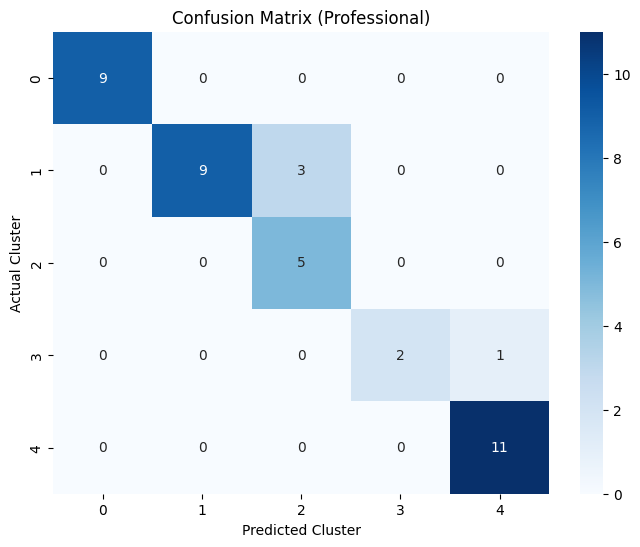

In [43]:
# Confusion Matrix Graph
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Professional)")
plt.xlabel("Predicted Cluster")
plt.ylabel("Actual Cluster")
plt.show()

### Confusion Matrix Visualization

A confusion matrix is visualized using a heatmap to show the number of correct and incorrect predictions made by the model for each cluster. This helps in understanding which clusters are being classified accurately and where the model makes errors.

**Tools Used:**
- **`seaborn`**: For creating the heatmap.
- **`matplotlib.pyplot`**: For displaying the plot.

In [44]:
logging.info("Model Training Complete")

In [45]:
# Final Prediction Cell
#  Naye Customer ka data banayenge (Bilkul training format jaisa)
# Note: Humne model ko sirf 'Age' aur 'Income' par train kiya tha.
new_data_df = pd.DataFrame({
    'Age': [40],
    'Annual Income (k$)': [80]
})

## Making Predictions for New Customers and Business Insights

This final section demonstrates how to use the trained model to predict the segment for a new customer and then translates the numerical clusters into meaningful business profiles. This provides actionable insights for marketing and business strategies.

### Predicting for a New Customer

This cell simulates predicting the cluster for a new customer with specific 'Age' and 'Annual Income'. The `new_data_df` is created in the same format as the training data, and the `best_model`'s `predict` method is used to get the cluster assignment.

In [46]:
#  Prediction (Pipeline khud scaling handle karega)
prediction = best_model.predict(new_data_df)

### Displaying New Customer Prediction

This prints the predicted cluster for the new customer. Since the pipeline includes scaling, the `best_model` automatically handles the scaling of `new_data_df` before making the prediction.

In [47]:
# Result Show karna
print(f"New Customer Profile: Age 40, Income $80k")
print(f"Predicted Group: Cluster {prediction[0]}")

New Customer Profile: Age 40, Income $80k
Predicted Group: Cluster 2


### Assigning Cluster Labels to Original Data

To facilitate business interpretation, the predicted cluster labels (`y`) are added as a new column, `Cluster_Label`, to the original `Customer` DataFrame. This allows for direct analysis of customer attributes within each segment.

In [48]:
# BUSINESS INSIGHTS (CLUSTER NAMING)
# Hum original data mein Cluster labels add kar rahe hain analysis ke liye
Customer['Cluster_Label'] = y

### Cluster Profile Analysis

This step calculates the average 'Annual Income (k$)' and 'Spending Score (1-100)' for each identified cluster. These average values are crucial for defining the characteristics of each customer segment.

In [49]:
# Har cluster ka Average Income aur Average Score nikalte hain
cluster_analysis = Customer.groupby('Cluster_Label')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

### Function to Name Clusters

A custom function, `name_cluster`, is defined to assign descriptive, human-readable names to each customer cluster based on their average annual income and spending score. This transforms numerical clusters into actionable business segments (e.g., 'Big Spenders', 'Savers').

In [50]:
# Function jo numbers dekh kar naam dega
def name_cluster(row):
    income = row['Annual Income (k$)']
    score = row['Spending Score (1-100)']

    if income > 70 and score > 60:
        return "Big Spenders (Target Audience)"  # Paisa bhi hai, kharch bhi karte hain
    elif income > 70 and score < 40:
        return "Savers (Careful)"                # Paisa hai, par bacha kar rakhte hain
    elif income < 40 and score > 60:
        return "Impulsive (Careless)"            # Paisa kam hai, par uda dete hain
    elif income < 40 and score < 40:
        return "Sensible (Frugal)"               # Paisa kam hai, soch samajh kar kharch karte hain
    else:
        return "Standard (Middle Class)"         # Average log

### Final Business Report

This section applies the `name_cluster` function to the `cluster_analysis` DataFrame to generate a comprehensive business report. It displays the average income, spending score, and the assigned profile name for each cluster, providing clear, actionable insights for marketing strategies.

In [51]:
# Apply naming logic
cluster_analysis['Profile Name'] = cluster_analysis.apply(name_cluster, axis=1)

print("\n" + "="*50)
print("FINAL BUSINESS REPORT")
print("="*50)
print(cluster_analysis)
print("="*50)


FINAL BUSINESS REPORT
               Annual Income (k$)  Spending Score (1-100)  \
Cluster_Label                                               
0                       54.382979               48.851064   
1                       86.102564               19.358974   
2                       86.100000               81.525000   
3                       26.750000               18.350000   
4                       41.092593               62.240741   

                                 Profile Name  
Cluster_Label                                  
0                     Standard (Middle Class)  
1                            Savers (Careful)  
2              Big Spenders (Target Audience)  
3                           Sensible (Frugal)  
4                     Standard (Middle Class)  


### Final Conclusion for the New Customer

This combines the predicted cluster for the new customer with the business profile names. It states the predicted cluster ID and the corresponding descriptive profile name, providing an immediate understanding of where a new customer fits within the established segments.

In [52]:
# Ab wapis check karte hain ke naya customer (Age 40, Income 80k) kis category mein hai
# Note: Humne upar predict kiya tha 'predicted_cluster[0]'
cluster_id = prediction[0]
profile_name = cluster_analysis.loc[cluster_id, 'Profile Name']

print(f"\nFinal Conclusion:")
print(f"The new customer (Age 40, Income $80k) belongs to Cluster {cluster_id}.")
print(f"Customer Profile: '{profile_name}'")


Final Conclusion:
The new customer (Age 40, Income $80k) belongs to Cluster 2.
Customer Profile: 'Big Spenders (Target Audience)'


In [53]:
logging.info("Pipeline Finished Successfully")